# Laboratório - Redes Bayesianas

> **Outputs pendentes**
>
> Este laboratório lê o arquivo `heart.csv`, que ainda não está
> disponível no repositório. A execução automática está desativada até
> que o dataset seja adicionado — o código abaixo é mostrado como
> referência, sem outputs.

## Ajustando Ambiente

In [ ]:
%%capture
!pip install pgmpy==1.0.0

In [ ]:
%%capture
!apt-get install libgraphviz-dev graphviz -y
!pip install pygraphviz

In [ ]:
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

## Objetivos de aprendizagem

Ao final deste laboratório, espera-se que você seja capaz de:

1.  Compreender a estrutura de uma Rede Bayesiana, identificando seus
    dois componentes principais: o Grafo Acíclico Dirigido (DAG) e as
    Tabelas de Probabilidade Condicional (CPTs).

2.  Interpretar como uma Rede Bayesiana representa relações de
    dependência entre variáveis e permite realizar inferência
    probabilística sob incerteza.

3.  Aplicar algoritmos de aprendizagem estrutural, como o Hill Climb
    Search, para construir uma Rede Bayesiana a partir de dados
    observacionais.

4.  Utilizar critérios de pontuação, como o BIC, para avaliar estruturas
    candidatas de Redes Bayesianas.

5.  Comparar redes aprendidas automaticamente com redes definidas a
    partir de conhecimento prévio, discutindo suas vantagens, limitações
    e interpretabilidade.

## Motivação

No tutorial anterior, vimos que a Teoria da Probabilidade fornece uma
base para a tomada de decisão racional em Inteligência Artificial,
especialmente quando lidamos com incerteza. Também exploramos o
Classificador Naive Bayes, uma ferramenta simples e eficiente que aplica
o Teorema de Bayes a múltiplas evidências.

Apesar de sua utilidade, o Naive Bayes depende de uma simplificação
forte: a suposição de que as evidências são condicionalmente
independentes entre si, dada a classe. Na prática, essa suposição nem
sempre é realista. Em muitos problemas do mundo real, variáveis estão
correlacionadas e podem influenciar umas às outras.

As Redes Bayesianas surgem como uma alternativa mais flexível e
interpretável. Elas combinam probabilidade com grafos, permitindo
representar relações de dependência entre variáveis. Uma Rede Bayesiana
trabalha com dois componentes principais:

- **Estrutura gráfica**, representada por um Grafo Acíclico Dirigido, ou
  DAG, que indica quais variáveis influenciam diretamente outras
  variáveis.
- **Quantificação probabilística**, representada pelas Tabelas de
  Probabilidade Condicional, ou CPTs, que descrevem numericamente essas
  relações.

Ao longo deste laboratório, veremos como essas duas partes se combinam
para permitir inferência probabilística em cenários de incerteza.

## Redes Bayesianas

Para compreender os fundamentos de Redes Bayesianas, utilizaremos o
exemplo clássico **Burglars and Earthquakes** (Assaltantes e
Terremotos). Burglars and Earthquakes é um modelo que compreende cinco
variáveis binárias relacionadas a um sistema de segurança residencial:

- **Causas Raiz:** Ocorrência de um **Assalto (Burglary)** e Ocorrência
  de um **Terremoto (Earthquake)**, ambas com baixas probabilidades a
  priori.
- **Efeito Central:** O disparo do **Alarme (Alarm)**, que é o efeito
  comum causado por Assalto ou Terremoto.
- **Observações (Evidência):** As ligações de **John (JohnCalls)** e
  **Mary (MaryCalls)**, que são observações que dependem diretamente do
  Alarme.

A estrutura da rede modela o seguinte fluxo causal: o Assalto e o
Terremoto (causas independentes) levam ao Alarme (efeito), e o Alarme,
por sua vez, leva às chamadas de John e Mary. Este exemplo será usado
para demonstrar como o DAG e as CPTs quantificam essas relações e
permitem a inferência.

<figure>
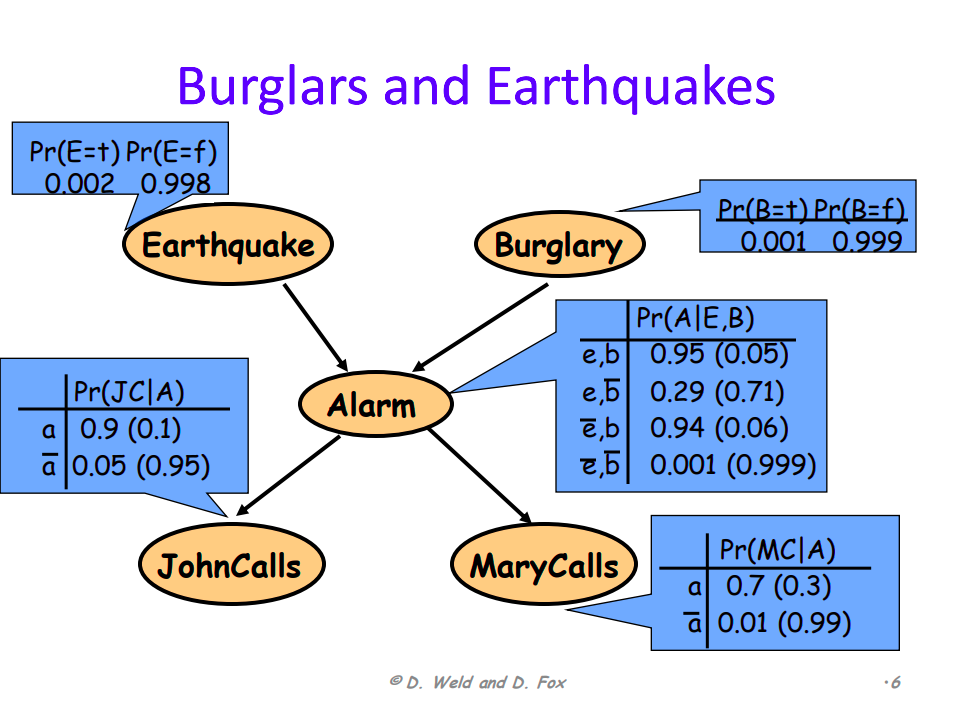
<figcaption aria-hidden="true">image.png</figcaption>
</figure>

Explicação

A imagem apresenta o clássico modelo de Rede Bayesiana “Assalto e
Terremoto”, que ilustra como o Alarme (`Alarm`) é influenciado por duas
causas independentes e como as observações (`JohnCalls`, `MaryCalls`)
são influenciadas pelo Alarme.

#### 1. Probabilidades A Priori (Nós Raiz)

Estes são os nós que não têm pais, representando a probabilidade basal
de ocorrência:

| Variável | Probabilidade | Interpretação |
|:-----------------------|:-----------------------|:-----------------------|
| **Earthquake (E=t)** | $P(E=t) = 0.002$ | A chance de haver um **Terremoto** é de **0.2%** (Muito rara). |
| **Burglary (B=t)** | $P(B=t) = 0.001$ | A chance de haver um **Assalto** é de **0.1%** (Extremamente rara). |

#### 2. Probabilidade Condicional do Alarme (A)

Esta é a CPT que mostra a probabilidade do Alarme disparar, dado o
estado de seus pais:

| Condição (E, B) | $P(A=t \mid E, B)$ | $P(A=f \mid E, B)$ | Interpretação |
|:-----------------|:-----------------|:-----------------|:-----------------|
| $E=t, B=t$ | $0.95$ | $0.05$ | Com Terremoto E Assalto, o Alarme dispara **95%** das vezes. |
| $E=f, B=t$ | $0.94$ | $0.06$ | **SÓ Assalto**, o Alarme dispara **94%** das vezes (excelente detector de assalto). |
| $E=t, B=f$ | $0.29$ | $0.71$ | **SÓ Terremoto**, o Alarme dispara apenas **29%** das vezes (detector ruim de terremoto). |
| $E=f, B=f$ | $0.001$ | $0.999$ | **NÃO há nada**, Alarme dispara apenas **0.1%** (baixa taxa de falso positivo). |

#### 3. Probabilidades Condicionais das Chamadas

A probabilidade de ligar é condicionada *apenas* ao estado do Alarme.

#### JohnCalls (JC)

| Condição (A) | $P(JC=t \mid A)$ | $P(JC=f \mid A)$ | Interpretação |
|:-----------------|:-----------------|:-----------------|:-----------------|
| $A=t$ | $0.9$ | $0.1$ | Se o Alarme disparou, **John liga 90%** das vezes (é mais confiável). |
| $A=f$ | $0.05$ | $0.95$ | Se o Alarme está desligado, John liga por engano $5\%$ das vezes. |

#### MaryCalls (MC)

| Condição (A) | $P(MC=t \mid A)$ | $P(MC=f \mid A)$ | Interpretação |
|:-----------------|:-----------------|:-----------------|:-----------------|
| $A=t$ | $0.7$ | $0.3$ | Se o Alarme disparou, **Mary liga 70%** das vezes (menos confiável que John). |
| $A=f$ | $0.01$ | $0.99$ | Se o Alarme está desligado, Mary liga por engano apenas **1%** das vezes (mais precisa em não ligar). |

### O Grafo Acíclico Dirigido (DAG)

O DAG é uma representação visual e matemática das relações entre as
variáveis. Ele é chamado de Dirigido porque todas as conexões têm um
sentido (indicado por uma seta: $A \to B$), modelando o fluxo de
influência ou causalidade. Ele é Acíclico porque é estritamente proibido
que haja um caminho que comece e termine no mesmo nó, garantindo que não
existam laços de autorreferência causal ou dependências circulares.

#### Componentes do DAG

O DAG é composto por dois elementos fundamentais:

- **Nós (Nodes):**
  - Representam as **variáveis aleatórias** do domínio. Cada variável
    (como “Assalto”, “Alarme”, “Temperatura”) deve ocupar um único nó.
  - Podem ser binárias (Verdadeiro/Falso), discretas (Baixo/Médio/Alto)
    ou, em casos mais avançados, contínuas.
- **Arestas Dirigidas (Directed Edges):**
  - Representam as **dependências causais ou probabilísticas diretas**
    entre as variáveis.
  - Uma aresta de $A \to B$ significa que $A$ é um **pai** (*parent*) de
    $B$, e $B$ é um **filho** (*child*) de $A$.
  - Na maioria dos modelos, a direção da aresta representa o fluxo
    causal, ou seja, a causa aponta para o efeito.

#### Exemplo clássico - Alarme de Casa

Na rede *Burglars and Earthquakes*, a estrutura do DAG mostra que: \* O
*Earthquake* ($E$) e o *Burglary* ($B$) são **causas raiz** que apontam
para o *Alarm* ($A$) ($E \to A \leftarrow B$). \* O *Alarm* ($A$) aponta
para *JohnCalls* ($JC$) e *MaryCalls* ($MC$) ($A \to JC$ e $A \to MC$).

O DAG nos diz que, se o Alarme for conhecido, a ocorrência de um Assalto
não afeta a probabilidade de Mary Ligar, pois o Alarme “bloqueia” essa
informação (um conceito que será detalhado na D-Separação).

Qual a importancia do DAG?

A estrutura do DAG codifica a hipótese de independência condicional da
rede: uma variável é considerada dependente apenas de seus pais diretos.

### Tabelas de Probabilidade Condicional (CPTs)

Se o Grafo Acíclico Dirigido (DAG) é o mapa das dependências (o
componente *qualitativo*), as **Tabelas de Probabilidade Condicional
(CPTs)** são a chave que quantifica essas dependências (o componente
*quantitativo*). O conjunto de todas as CPTs da rede é o que fornece a
informação numérica necessária para realizar a inferência.

**1. Definição e Quantificação da Causalidade**

Cada nó $X$ na rede é associado a uma CPT. Esta tabela especifica a
probabilidade de a variável $X$ assumir cada um dos seus estados,
**condicionada à combinação de estados dos seus pais diretos**.

- **A Regra Local:** A regra probabilística para cada nó é dada por
  $P(X | \mathbf{Pais}(X))$.
- **A Inserção dos Dados:** As entradas das CPTs são probabilidades que
  podem ser obtidas de várias maneiras:
  - **Frequência de Dados:** Aprendidas a partir de grandes conjuntos de
    dados de treinamento.
  - **Conhecimento de Especialistas:** Estimadas por especialistas no
    domínio (por exemplo, um médico).

**2. Tamanho e Escopo das CPTs**

O número de parâmetros (entradas) em uma CPT depende apenas do número de
estados do nó e do número de combinações de estados possíveis de seus
pais.

- **CPT de Nós Raiz (Sem Pais):**
  - Para nós que não têm pais (as causas primárias, como **Assalto** ou
    **Terremoto**), a CPT é simplesmente a **Probabilidade A Priori**
    (incondicional), $P(X)$.
- **CPT de Nós com Pais:**
  - Para variáveis como o **Alarme ($L$)**, que tem dois pais ($A$ e
    $T$), a CPT deve listar a probabilidade de $L$ para cada uma das
    combinações dos estados de $A$ e $T$.

#### Exemplo clássico - Alarme de Casa

Na Rede *Burglars and Earthquakes*, o nó **Alarme ($A$)** possui dois
pais: **Terremoto ($E$)** e **Assalto ($B$)**. Assumindo que todas são
variáveis binárias (Verdadeiro/Falso), a CPT deve cobrir
$2 \times 2 = \mathbf{4}$ combinações de estados dos pais:

A CPT para $P(A | E, B)$ é apresentada com valores que demonstram a
influência combinada das causas:

| Terremoto ($E$) | Assalto ($B$) | Notação Simplificada | $P(A=\text{Verdadeiro})$ | $P(A=\text{Falso})$ |
|:-------------:|:-------------:|:-------------:|:-------------:|:-------------:|
| Verdadeiro ($\mathbf{e}$) | Verdadeiro ($\mathbf{b}$) | e, b | $0.95$ | $0.05$ |
| Verdadeiro ($\mathbf{e}$) | Falso ($\neg \mathbf{b}$) | e, $\neg$b | $0.29$ | $0.71$ |
| Falso ($\neg \mathbf{e}$) | Verdadeiro ($\mathbf{b}$) | $\neg$e, b | $0.94$ | $0.06$ |
| Falso ($\neg \mathbf{e}$) | Falso ($\neg \mathbf{b}$) | $\neg$e, $\neg$b | $0.001$ | $0.999$ |

- O número total de entradas para a CPT de $A$ é
  $4 \times 2 = \mathbf{8}$ entradas.
- Observe que se ambas as causas são falsas
  ($\neg \mathbf{e}, \neg \mathbf{b}$), a probabilidade de o alarme
  disparar é extremamente baixa ($0.001$), indicando um erro ou ruído na
  medição.
- Se o Assalto é Verdadeiro ($0.94$) ou ambos são Verdadeiros ($0.98$),
  a probabilidade de o alarme disparar é alta, mas a combinação de ambos
  é apenas marginalmente maior do que um assalto sozinho.

### Representação Compacta

O cerne da eficiência e da escalabilidade da Rede Bayesiana reside em
como ela combina a estrutura do DAG (dependências) e as CPTs
(quantificação) para evitar o problema exponencial da Distribuição de
Probabilidade Conjunta Completa ($\mathbf{O(2^n)}$).

**1. A Fatoração Baseada no Grafo**

A RB faz isso explorando a propriedade de **independência condicional**
codificada em seu DAG. Graças à estrutura acíclica dirigida, podemos
assumir que cada nó é condicionalmente independente de todos os seus
**não-descendentes**, **dado o conhecimento de seus pais**.

Essa premissa nos permite decompor a distribuição conjunta de todas as
variáveis ($X_1, \ldots, X_n$) em um produto de termos menores e
gerenciáveis. Esta é a **Fórmula da Fatoração da Rede Bayesiana**:

$$\mathbf{P}(X_1, \ldots, X_n) = \prod_{i=1}^{n} P(X_i|\mathbf{Pais}(X_i))$$

**Onde:** $\mathbf{Pais}(X_i)$ é o conjunto de pais diretos da variável
$X_i$.

#### Exemplo clássico - Alarme de Casa

Usando o exemplo clássico de 5 variáveis ($E$ - Terremoto, $B$ -
Assalto, $A$ - Alarme, $JC$ - John Liga, $MC$ - Mary Liga), a
probabilidade conjunta de um cenário específico ($E, B, A, JC, MC$) é
calculada como:

$$P(E, B, A, JC, MC) = P(E) \cdot P(B) \cdot P(A|E, B) \cdot P(JC|A) \cdot P(MC|A)$$

- **$P(E)$ e $P(B)$:** Vêm das CPTs dos nós raiz, que não têm pais.
- **$P(A | E, B)$:** Vêm da CPT do alarme, condicionada aos seus pais
  $E$ e $B$.
- **$P(JC | A)$ e $P(MC | A)$:** Vêm das CPTs das ligações,
  condicionadas ao seu único pai, $A$.

**2. O Ganho da Escalabilidade**

Essa fatoração é o que resolve a inescalabilidade.

- A FJD inteira, para 5 variáveis binárias, exigiria $2^5 = \mathbf{32}$
  entradas.
- Ao invés disso, armazenamos apenas as probabilidades nas CPTs:
  - $P(E)$: 2 entradas
  - $P(B)$: 2 entradas
  - $P(A | E, B)$: 8 entradas
  - $P(JC | A)$: 4 entradas
  - $P(MC | A)$: 4 entradas
  - **Total:** $2+2+8+4+4 = \mathbf{20}$ entradas.

Neste pequeno exemplo, a fatoração já reduz o número de parâmetros de 32
para 20. Em domínios com 100 variáveis, o número de entradas da FJD
seria $2^{100}$. Se a RB limitar o número máximo de pais ($k$) a, por
exemplo, $k=3$, o número total de entradas será apenas
$\mathbf{100 \cdot 2^3}$, o que é linear e gerenciável. Essa redução da
complexidade de **exponencial** para **quase linear** é a razão pela
qual as Redes Bayesianas se tornaram a ferramenta padrão para modelar
incerteza em grande escala.

### Princípio da Inferência

A Inferência na Rede Bayesiana (RB) é o mecanismo central para
**atualizar crenças**, agindo como uma aplicação sofisticada do Teorema
de Bayes para sistemas complexos.

**3. Fatoração e Otimização do Cálculo**

O processo é viabilizado pelo **Princípio de Fatoração**, que transforma
o cálculo inescalável da distribuição conjunta completa em uma
multiplicação eficiente de pequenas **Tabelas de Probabilidade
Condicional (CPTs)**. Este princípio permite que o agente gerencie a
complexidade ao trabalhar apenas com as dependências diretas de cada nó.

**4. Propagação da Informação**

Ao receber uma nova observação (evidência), a informação flui pela rede,
demonstrando a versatilidade da RB:

- **Raciocínio Preditivo (Causa $\to$ Efeito):** O agente usa as CPTs no
  sentido das setas para prever o que acontecerá com os efeitos (ex:
  $P(\text{sintoma} \mid \text{doença})$).
- **Raciocínio Diagnóstico (Efeito $\to$ Causa):** A informação flui
  inversamente, aplicando a **Regra de Bayes** para inferir a causa mais
  provável a partir de um sintoma observado (ex:
  $P(\text{doença} \mid \text{sintoma})$).

**5. Atingindo a Conclusão Final**

Para obter o resultado final, o agente utiliza o algoritmo *Eliminação
de Variáveis*:

- O algoritmo combina e multiplica os fatores relevantes (CPTs) afetados
  pela evidência.
- De forma sistemática, ele realiza a **soma das probabilidades sobre
  todas as variáveis não observadas** (processo conhecido como
  marginalização).
- Este procedimento isola a probabilidade da variável consultada,
  resultando na **distribuição de probabilidade *a posteriori*** que,
  uma vez normalizada, representa a conclusão mais racional e a chance
  atualizada de cada estado da *Query* ser verdadeiro.

## Exemplo Prático

### Cenário 01 - Demonstrando o poder da rede

No texto exemplo abaixo, usaremos o exemplo **Burglars and Earthquakes**
para resolver um problema de **raciocínio diagnóstico**. Lembre-se, o
objetivo final de construir uma Rede Bayesiana não é apenas modelar as
dependências, mas sim realizar inferência: **calcular as probabilidades
de eventos desconhecidos com base em novas evidências (observações)**.

Imaginem que recebemos ligações alarmadas de seus vizinhos, John e Mary.
Qual é a probabilidade de ter havido um Assalto, dado que John e Mary
ligaram?

Em termos probabilísticos, queremos calcular a Probabilidade a
Posteriori:

$$P(\text{Assalto} \mid \text{John Liga}, \text{Mary Liga}) = P(B=t \mid JC=t, MC=t)$$

#### O Fluxo Lógico de Implementação

A implementação da Rede Bayesiana usando a biblioteca `pgmpy` segue os
três pilares que acabamos de definir:

- **Definição da Estrutura (DAG):** Criação do mapa causal da rede,
  definindo os nós e as arestas de dependência.
- **Quantificação (CPTs):** Inserção das Tabelas de Probabilidade
  Condicional com os valores do domínio, garantindo que a fatoração seja
  possível.
- **Inferência:** Utilização de um algoritmo de inferência para
  percorrer a rede, combinar as probabilidades condicionais e calcular a
  probabilidade a posteriori desejada.

#### Construindo DAG

In [ ]:
# O modelo é definido pelas arestas (tuplas de (pai, filho))
alarm_model = DiscreteBayesianNetwork([
    ("Burglary", "Alarm"),
    ("Earthquake", "Alarm"),
    ("Alarm", "JohnCalls"),
    ("Alarm", "MaryCalls")
])

print("Estrutura da Rede Definida:")
print("Nós:", alarm_model.nodes)
print("Arestas:", alarm_model.edges)

In [ ]:
print(">>> Estrutura da Rede Bayesiana (DAG)")

# Imprime todos os nós que fazem parte da rede
print("\nNÓS (Variáveis):")
print(sorted(alarm_model.nodes()))

# Imprime as ARESTAS (Relações Causa -> Efeito)
print("\nARESTAS (Relações Causa -> Efeito, ou seja, as 'setas'):")
# Cada tupla (A, B) significa A -> B
for u, v in alarm_model.edges():
    print(f"  {u} -> {v}")

#### Quantificação (CPTs)

In [ ]:
# CPT para Burglary (B) - Nó Raiz: P(B)
# [P(B=f), P(B=t)]
cpd_b = TabularCPD(
    variable="Burglary",
    variable_card=2,
    values=[[0.999], [0.001]] # P(B=f)=0.999, P(B=t)=0.001
)

# CPT para Earthquake (E) - Nó Raiz: P(E)
# [P(E=f), P(E=t)]
cpd_e = TabularCPD(
    variable="Earthquake",
    variable_card=2,
    values=[[0.998], [0.002]] # P(E=f)=0.998, P(E=t)=0.002
)

# CPT para Alarm (A) - Condicional: P(A | E, B)
# As colunas são ordenadas pelo estado dos pais (E, B)
# Ordem das colunas: (f, f), (f, t), (t, f), (t, t)
# Ordem dos pais no 'evidence' deve coincidir com a ordem das colunas
cpd_a = TabularCPD(
    variable="Alarm",
    variable_card=2,
    values=[
        # P(A=f | E, B)
        [0.999, 0.06, 0.71, 0.05],
        # P(A=t | E, B)
        [0.001, 0.94, 0.29, 0.95]
    ],
    evidence=["Earthquake", "Burglary"],
    evidence_card=[2, 2] # 2 estados para E, 2 estados para B
)

In [ ]:
# CPT para JohnCalls (JC) - Condicional: P(JC | A)
# Colunas: A=f, A=t
cpd_jc = TabularCPD(
    variable="JohnCalls",
    variable_card=2,
    values=[
        # P(JC=f | A)
        [0.95, 0.1],
        # P(JC=t | A)
        [0.05, 0.9]
    ],
    evidence=["Alarm"],
    evidence_card=[2]
)

# CPT para MaryCalls (MC) - Condicional: P(MC | A)
# Colunas: A=f, A=t
cpd_mc = TabularCPD(
    variable="MaryCalls",
    variable_card=2,
    values=[
        # P(MC=f | A)
        [0.99, 0.3],
        # P(MC=t | A)
        [0.01, 0.7]
    ],
    evidence=["Alarm"],
    evidence_card=[2]
)

In [ ]:
# Adicionando todas as CPTs ao modelo
alarm_model.add_cpds(cpd_b, cpd_e, cpd_a, cpd_jc, cpd_mc)

# Verificando se as CPTs estão coerentes com a estrutura
print("\nModelo Validado:", alarm_model.check_model())

In [ ]:
print(">>> Tabelas de Probabilidade Condicional (CPTs)")

# Itera sobre todos os nós do modelo
for node in alarm_model.nodes():
    # Obtém a CPT do nó atual
    cpd = alarm_model.get_cpds(node)

    print(f"\nCPT para o nó: {node}")
    # O método 'print' do objeto cpd exibe a tabela formatada
    print(cpd)
    print("-" * 30)

#### Inferência

In [ ]:
# Inicializando o motor de inferência (Variable Elimination é um algoritmo comum)
alarm_infer = VariableElimination(alarm_model)

O que é Variable Elimination?

A **Eliminação de Variáveis** é o principal algoritmo de inferência
exata em Redes Bayesianas. A sua função é responder à consulta de
probabilidade (ex: $P(\text{Assalto} \mid \text{Ligações})$) de forma
eficiente, sem nunca ter que calcular a tabela gigantesca da
Distribuição Conjunta Completa.

O método trabalha com a seguinte intuição:

#### Foco Local em vez de Visão Geral

Em vez de tentar calcular a probabilidade de **toda a rede** de uma vez,
o algoritmo foca-se em uma área local, lidando com a incerteza variável
por variável. Ele usa as CPTs locais (as “regras” da rede) para calcular
a probabilidade de uma pequena parte e só então move-se para a próxima.

#### “Acertar as Contas” com a Incerteza

Quando o agente encontra uma variável que **não foi observada** (como
`Terremoto`), mas que é crucial para o cálculo da *Query*, ele não pode
simplesmente ignorá-la.

- O agente precisa **“acertar as contas”** com essa variável: ele
  **soma** as probabilidades de todos os seus estados possíveis. Essa
  soma (marginalização) garante que ele contabilize a incerteza gerada
  por essa variável *antes* de eliminá-la do cálculo.
- **A “Eliminação”:** Após somar todas as suas possibilidades, a
  variável pode ser **eliminada** do cálculo restante, pois o seu
  impacto total já foi transferido para os fatores vizinhos.

#### O Segredo da Escalabilidade: Somar Antes

O principal segredo da eficiência do algoritmo é a ordem das operações:
ele **soma sobre os estados de uma variável irrelevante *antes* de
multiplicar** pelos outros fatores. Isso evita que o agente crie e
armazene tabelas intermediárias gigantescas, tornando a inferência em
redes com dezenas de variáveis uma operação rápida e escalável.

Portanto, a **Eliminação de Variáveis** é uma estratégia para lidar com
a incerteza da rede de forma incremental, eliminando variáveis
irrelevantes uma de cada vez após “acertar as contas” com todas as suas
possibilidades.

In [ ]:
# Inferência: Qual é a probabilidade de ter havido um Assalto (Burglary)
# dado que John ligou (JohnCalls=t) E Mary ligou (MaryCalls=t)?
prob_burglary = alarm_infer.query(
    variables=["Burglary"],
    evidence={
        "JohnCalls": 1, # 1 = True/t
        "MaryCalls": 1
        }
)

# O output é um objeto Factor. Imprimimos a tabela de probabilidade resultante
print("Probabilidade de Assalto, dado que John e Mary ligaram:")
print(prob_burglary)

In [ ]:
print(f"A probabilidade de *não ter havido assalto* (Burglary=0) é de {prob_burglary.values[0]:.2%}.")
print(f"A probabilidade de *ter havido assalto* (Burglary=1) é de {prob_burglary.values[1]:.2%}.\n")

#### Interpretação

Antes das ligações, a probabilidade de Assalto era extremamente baixa,
pois $P(B=t)=0.001$. No entanto, quando observamos que John e Mary
ligaram, essa evidência aumenta substancialmente a probabilidade
posterior de Assalto.

Esse resultado mostra o poder do raciocínio diagnóstico em Redes
Bayesianas: partimos de efeitos observados, como as chamadas dos
vizinhos, e inferimos a probabilidade de causas não observadas, como a
ocorrência de um assalto. Ainda assim, a rede não fornece uma resposta
binária do tipo “houve” ou “não houve” assalto. Ela fornece uma
distribuição de probabilidade, permitindo representar a incerteza de
forma explícita.

Portanto, a principal lição deste exemplo é que evidências indiretas
podem alterar fortemente nossa crença sobre uma hipótese, mesmo quando
essa hipótese é rara a priori.

### Cenário 02 - Construção as cegas da Redes Bayesianas

No exemplo abaixo, iremos trabalhar com o **Dataset Heart Disease**, que
é um conjunto de registros médicos utilizado para prever a presença de
doença cardíaca em um paciente. O dataset é uma coleção de registros
médicos, originalmente compilada pela UCI Machine Learning Repository a
partir de quatro fontes.

**O nosso objetivo é prever a presença de doença cardíaca com base em 13
atributos clínicos.**

Para baixar o dataset, por favor, clique aqui em
[Heart](https://drive.google.com/file/d/1laJe29EuRuLZTmPOx_2UPgcPfzcUX3yL/view?usp=drive_link).
Após efetuar o download, por favor, coloque-o dentro da sua pasta
`contents` ou conecte-se ao seu Google Drive pessoal (veja o
procedimento abaixo).

In [ ]:
# Importações do pgmpy e de outras bibliotecas
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.inference import VariableElimination
from pgmpy.estimators import BayesianEstimator

# Para o pré-processamento
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Visualizacao
import networkx as nx
import matplotlib.pyplot as plt

# Layout hierárquico com Graphviz
from networkx.drawing.nx_agraph import graphviz_layout

# Google drive
from google.colab import drive

In [ ]:
# from google.colab import drive
drive.mount('/content/drive')

#### Discretizando o conjunto de dados

Para construir uma Rede Bayesiana Discreta (como a implementada no
pgmpy), as variáveis originais do tipo Inteiro (age, chol, trestbps,
etc.) precisaram ser transformadas em variáveis categóricas (age_cat,
chol_cat, trestbps_cat) no Passo 2 por meio do processo de
Discretização.

In [ ]:
# Carrega o arquivo CSV em um DataFrame do Pandas
# Se o nome do seu arquivo CSV for diferente (ex: 'heart_disease_uci.csv'), ajuste o nome aqui.
df_heart = pd.read_csv('/content/heart.csv')

print(">>> Dataset de Doença Cardíaca Carregado com Sucesso! Dimensões:")
print(f"Linhas: {df_heart.shape[0]}, Colunas: {df_heart.shape[1]}")

In [ ]:
df_heart.head()

In [ ]:
#df_heart[df_heart["age", "age_cat]]

In [ ]:
import pandas as pd

# Conversão de Variáveis Categóricas e Numéricas Discretas para String/Object
# As variáveis categóricas já devem ser tratadas como strings para pgmpy
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in categorical_cols:
    df_heart[col] = df_heart[col].astype(str)

# Discretização de Variáveis Numéricas (Quantização)
# Discretizar em 3 faixas (bins) com rótulos

# Idade (age)
df_heart['age_cat'] = pd.cut(df_heart['age'], bins=[29, 45, 58, 77], \
                             labels=['Jovem', 'Meia-Idade', 'Idoso'],\
                             include_lowest=True)

# Colesterol (chol) - 3 faixas com base nos quartis (aproximadamente)
df_heart['chol_cat'] = pd.cut(df_heart['chol'], bins=[125, 200, 260, 564],\
                              labels=['Normal', 'Alto', 'Muito Alto'],\
                              include_lowest=True)

# Pressão Arterial (trestbps)
df_heart['trestbps_cat'] = pd.cut(df_heart['trestbps'], bins=[93, 120, 140, 200],\
                                  labels=['Normal', 'Elevada', 'Hipertensao'],\
                                  include_lowest=True)

# Frequência Cardíaca Máxima (thalach)
df_heart['thalach_cat'] = pd.cut(df_heart['thalach'], bins=[71, 120, 150, 202],\
                                   labels=['Baixa', 'Media', 'Alta'],\
                                   include_lowest=True)

# Depressão do Segmento ST (oldpeak)
df_heart['oldpeak_cat'] = pd.cut(df_heart['oldpeak'], bins=[0, 1.0, 2.5, 6.2],\
                                   labels=['Baixo', 'Moderado', 'Alto'],\
                                   include_lowest=True)

# Colunas finais a serem usadas na RB
final_columns = ['age_cat', 'sex', 'cp', 'trestbps_cat', 'chol_cat', 'fbs',\
                 'restecg', 'exang', 'slope', 'ca', 'thal', 'thalach_cat', 'oldpeak_cat', 'target']

df_final = df_heart[final_columns].copy()

Descrição do conjunto de dados

#### Variável-Alvo (Target)

A variável principal que seu agente probabilístico tentará prever é a
que define o diagnóstico:

| Variável | Descrição |
|:-----------------------------------|:-----------------------------------|
| **`target`** | **Presença de Doença Cardíaca.** É uma variável discreta binária: **`0`** = Ausência da doença; **`1`** = Presença da doença. |

#### Variáveis Demográficas e Fisiológicas (Nós Raiz e Intermediários)

Estas variáveis descrevem as condições basais do paciente:

| Variável | Tipo (Original) | Detalhe |
|:-----------------------|:-----------------------|:-----------------------|
| **`age`** | Inteiro | Idade do paciente (em anos). |
| **`sex`** | Categórica | Sexo do paciente (`0` = Feminino, `1` = Masculino). |
| **`trestbps`** | Inteiro | **Pressão Arterial de Repouso** (em mm Hg). |
| **`chol`** | Inteiro | **Colesterol Sérico** (em mg/dL). |
| **`fbs`** | Categórica | **Açúcar no Sangue em Jejum** (\> 120 mg/dL): `1` para risco/diabetes, `0` caso contrário. |
| **`restecg`** | Categórica | **Resultados do Eletrocardiograma de Repouso** (valores `0`, `1`, `2`). |

#### Variáveis de Sintomas e Testes de Estresse

Estas variáveis resultam de testes ou observações mais diretas de
sintomas cardíacos:

| Variável | Tipo (Original) | Detalhe |
|:-----------------------|:-----------------------|:-----------------------|
| **`cp`** | Categórica | **Tipo de Dor no Peito** (4 valores que indicam o grau de angina). |
| **`thalach`** | Inteiro | **Frequência Cardíaca Máxima Atingida** durante o exercício. |
| **`exang`** | Categórica | **Angina Induzida por Exercício:** Dor no peito após o exercício (`1` = Sim; `0` = Não). |
| **`oldpeak`** | Inteiro/Float | **Depressão do Segmento ST** induzida por exercício (medida de anormalidade cardíaca). |
| **`slope`** | Categórica | **Inclinação do Segmento ST** de pico de exercício (3 valores). |
| **`ca`** | Inteiro (0-3) | **Número de Vasos Principais** com oclusão, coloridos por fluoroscopia. |
| **`thal`** | Categórica | **Defeito Tálio-Cintilográfico** (Thalium Stress Test): `0` = normal, `1` = defeito fixo, `2` = defeito reversível. |

In [ ]:
df_final.head()

#### Construindo DAG

In [ ]:
# Inicialização com os dados prontos
est = HillClimbSearch(data=df_final)

# Inicializa o objeto de pontuação BICScore com os dados
scoring_method = BIC(data=df_final)

# Estima o melhor modelo usando o BICScore
# O HillClimbSearch usa o BICScore para guiar sua busca
best_model = est.estimate(
    scoring_method=scoring_method, # Passa o objeto BICScore inicializado
    max_iter=100
)

Explicação

Aqui estamos construindo a estrutura da Rede Bayesiana automaticamente a
partir dos dados usando o algoritmo **HillClimbSearch** em conjunto com
o critério de pontuação **BIC**. O HillClimbSearch funciona como uma
busca local: ele começa com uma estrutura inicial de rede e, a cada
passo, testa pequenas modificações no grafo, como adicionar, remover ou
inverter arestas entre variáveis. Cada estrutura candidata é avaliada
por uma função de pontuação. Neste laboratório, usamos o **BIC**
(*Bayesian Information Criterion*), que mede o quanto a estrutura
explica bem os dados, mas penaliza modelos excessivamente complexos.
Assim, o algoritmo procura uma rede que represente boas dependências
estatísticas entre as variáveis sem adicionar arestas desnecessárias. O
resultado é uma estrutura aprendida automaticamente, útil para explorar
padrões nos dados, mas que deve ser interpretada com cuidado, pois
associações estatísticas não implicam necessariamente relações causais.

In [ ]:
# Cria a Rede Bayesiana com as arestas aprendidas
model = DiscreteBayesianNetwork(best_model.edges())

print(">>> Estrutura da Rede Bayesiana Aprendida")

# Imprime todos os nós que fazem parte da rede
print("\nNÓS (Variáveis):")
print(sorted(model.nodes()))

# Imprime as ARESTAS (Relações Causa -> Efeito)
print("\nARESTAS (Relações Causa -> Efeito, ou seja, as 'setas'):")
# Cada tupla (A, B) significa A -> B
for u, v in best_model.edges():
    print(f"  {u} -> {v}")

In [ ]:
# Converter o modelo pgmpy em um objeto NetworkX Graph
graph = nx.DiGraph(model.edges())

# Adicionar os nós que podem ter sido isolados
graph.add_nodes_from(model.nodes())

# Configuração do layout para visualização (usando o layout circular para clareza)
pos = nx.shell_layout(graph)

# Desenhar o grafo
plt.figure(figsize=(10, 8))
nx.draw(graph,
        pos,
        with_labels=True,
        node_size=3000,
        node_color="lightblue",
        font_size=10,
        font_weight="bold",
        arrows=True,
        arrowsize=20)

#### Quantificação (CPTs)

Com a estrutura definida, o agente agora aprende as Tabelas de
Probabilidade Condicional (CPTs) contando as frequências nos dados.

In [ ]:
# Estima as CPTs a partir dos dados (Aprendizagem de Parâmetros)
# Usando o 'MaximumLikelihoodEstimator' que conta as frequências
model.fit(data = df_final)

print(">>> CPTs Aprendidas (Exemplo - Nó Alvo 'target'):")
# Exibe a CPT do nó alvo 'target'
print(model.get_cpds('target'))

In [ ]:
print(">>> Tabelas de Probabilidade Condicional (CPTs) Aprendidas")
print("Visualizando CPTs para todos os nós do modelo:\n")

# O método get_cpds() retorna a CPT para um nó específico.
for node in model.nodes():
    # Obtém a CPT do nó
    cpd = model.get_cpds(node)

    # Imprime o nó e sua CPT formatada
    print(f"CPD para o nó: {node}")
    print(cpd)
    print("-" * 50)

#### Inferência

Finalmente, usamos o algoritmo de Eliminação de Variáveis para fazer uma
consulta, calculando a probabilidade de doença (target=1) dado um novo
paciente (evidência).

In [ ]:
# Inicializa o motor de inferência (Algoritmo de Eliminação de Variáveis)
infer = VariableElimination(model)

Explicação

A função **VariableElimination** implementa um algoritmo de inferência
exata em Redes Bayesianas. Sua ideia central é calcular a probabilidade
de uma variável de interesse considerando as evidências observadas, sem
precisar enumerar explicitamente todas as combinações possíveis da rede.
Para isso, o algoritmo utiliza as Tabelas de Probabilidade Condicional
(CPTs), fixa os valores das variáveis observadas como evidência e
elimina, uma a uma, as variáveis que não fazem parte da consulta. Essa
eliminação é feita por meio de operações de multiplicação e soma sobre
fatores probabilísticos. Ao final do processo, resta uma distribuição de
probabilidade normalizada para a variável consultada. Assim, quando
perguntamos, por exemplo,
$P(\text{target} \mid \text{sex}, \text{age_cat}, \text{cp})$, o
algoritmo combina as informações relevantes da rede e retorna a
probabilidade posterior de cada valor possível de `target`.

In [ ]:
# Cenário de Diagnóstico:
# Paciente: Sexo Masculino (sex=1), Idade de Meia-Idade (age_cat=Meia-Idade),
# Tem Dor no Peito tipo 2 (cp=2), Não tem Angina Induzida por Exercício (exang=0).

query_result = infer.query(
    variables=['target'],
    evidence={
        'sex': '1',
        'age_cat': 'Meia-Idade',
        'cp': '2',
        'exang': '0'
    }
)

In [ ]:
# O resultado é uma distribuição de probabilidade
prob_doenca_presente = query_result.values[1] # Probabilidade para target = 1
prob_doenca_ausente = query_result.values[0] # Probabilidade para target = 0

print(">>> Resultados da Inferência (Raciocínio Diagnóstico)")
print(f"Probabilidade de Doença Cardíaca (target=0): {prob_doenca_ausente:.4f}")
print(f"Probabilidade de Doença Cardíaca (target=1): {prob_doenca_presente:.4f}")

#### Interpretação

O nosso agente deduziu que, dadas as características de sexo masculino,
meia-idade e a presença de dor no peito tipo 2 (uma dor no peito que é
fortemente suspeita de ser de origem cardíaca), a chance de o paciente
realmente ter a Doença Cardíaca é de 70.79%.

Apesar de o paciente não ter angina induzida por exercício (exang=0) em
que Angina é o termo técnico para a dor no peito causada pela falta de
sangue no coração, e quando é induzida por esforço. Finalmente, o peso
combinado dos outros fatores (especialmente sexo e a presença do sintoma
cp=2) empurrou o diagnóstico para a alta probabilidade.

Este resultado ilustra o poder dos agentes probabilísticos: eles não
fornecem um diagnóstico binário (Sim/Não), mas sim uma distribuição de
probabilidade, permitindo que o profissional de saúde tome decisões
informadas sob incerteza.

### Cenário 03 - Construção da rede baseada em conhecimento prévio

Nos cenários anteriores, vimos duas situações distintas. No Cenário 01,
a estrutura da rede já era conhecida e usamos a rede para realizar
inferência. No Cenário 02, deixamos que o algoritmo aprendesse
automaticamente a estrutura da rede a partir dos dados.

Neste terceiro cenário, adotaremos uma abordagem intermediária e muito
comum em aplicações reais: a estrutura da Rede Bayesiana será definida
com base em conhecimento prévio do domínio.

Em problemas médicos, por exemplo, nem sempre é desejável permitir que
um algoritmo defina livremente todas as relações entre variáveis.
Algumas direções causais são mais plausíveis que outras. A idade pode
influenciar pressão arterial e colesterol, mas pressão arterial não
“causa” a idade. Da mesma forma, sintomas e exames podem informar o
diagnóstico, mas o diagnóstico em si não deve ser usado como causa das
características clínicas observadas no paciente.

Neste cenário, definiremos manualmente as arestas da rede usando uma
hipótese clínica simplificada. Depois, usaremos os dados apenas para
aprender as probabilidades condicionais, isto é, as CPTs.

#### Construindo o DAG com conhecimento de domínio

A estrutura abaixo representa uma hipótese simplificada sobre o
problema, construída a partir de conhecimento prévio. Neste cenário,
adotamos uma interpretação predominantemente **causal/generativa**:
variáveis demográficas e fatores clínicos antecedem o risco de doença,
enquanto sintomas e achados de exames são tratados como manifestações
observáveis associadas à presença de doença cardíaca.

- `age_cat` representa um fator demográfico antecedente, podendo
  influenciar variáveis fisiológicas como pressão arterial
  (`trestbps_cat`), colesterol (`chol_cat`), frequência cardíaca máxima
  (`thalach_cat`) e também o risco de doença cardíaca (`target`).

- `sex` também é tratado como uma variável demográfica antecedente,
  podendo influenciar diferenças fisiológicas e o risco associado à
  doença cardíaca.

- `chol_cat`, `trestbps_cat` e `fbs` representam fatores metabólicos e
  fisiológicos associados ao risco cardiovascular.

- `target` representa a presença ou ausência de doença cardíaca. Nesta
  modelagem, ele também é usado como causa provável de manifestações
  clínicas e achados diagnósticos.

- `cp`, `exang`, `oldpeak_cat`, `slope`, `thal`, `ca` e `restecg` são
  tratados como sintomas ou achados clínicos/exames que podem estar
  associados à presença da doença.

- Relações auxiliares, como `thalach_cat -> exang` e
  `oldpeak_cat -> slope`, representam dependências fisiológicas ou
  clínicas entre variáveis relacionadas ao teste de esforço.

Essa estrutura não deve ser interpretada como um modelo clínico
definitivo. Ela representa uma hipótese didática usada para mostrar como
o conhecimento prévio pode orientar a construção da Rede Bayesiana. Aqui
o nosso objetivo foi construir uma rede mais interpretável do que uma
estrutura aprendida automaticamente, mesmo que ela não seja
necessariamente a estrutura com melhor ajuste estatístico ao conjunto de
dados.

In [ ]:
# Estrutura definida manualmente com base em conhecimento prévio
# Cada tupla representa uma aresta: (variável_pai, variável_filha)

expert_edges = [
    # 1. Variáveis demográficas como antecedentes
    ("age_cat", "chol_cat"),
    ("age_cat", "trestbps_cat"),
    ("age_cat", "thalach_cat"),
    ("age_cat", "target"),

    ("sex", "thalach_cat"),
    ("sex", "target"),

    # 2. Fatores clínicos/metabólicos associados ao risco
    ("chol_cat", "target"),
    ("trestbps_cat", "target"),
    ("fbs", "target"),

    # 3. Doença como causa de manifestações clínicas e achados diagnósticos
    ("target", "cp"),
    ("target", "restecg"),
    ("target", "exang"),
    ("target", "oldpeak_cat"),
    ("target", "slope"),
    ("target", "thal"),
    ("target", "ca"),

    # 4. Relações fisiológicas auxiliares
    ("thalach_cat", "exang"),
    ("exang", "oldpeak_cat"),
    ("oldpeak_cat", "slope")
]

In [ ]:
expert_model = DiscreteBayesianNetwork(expert_edges)

print(">>> Estrutura da Rede Bayesiana definida por conhecimento prévio:")
print("\nNós:")
print(sorted(expert_model.nodes()))

print("\nArestas:")
for edge in expert_model.edges():
    print(f"{edge[0]} -> {edge[1]}")

#### Visualização do DAG

In [ ]:
# Layout hierárquico com Graphviz
from networkx.drawing.nx_agraph import graphviz_layout

graph = nx.DiGraph(expert_model.edges())
graph.add_nodes_from(expert_model.nodes())

plt.figure(figsize=(14, 8))
pos = graphviz_layout(graph, prog="dot")

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    edgecolors=None,
    font_size=10,
    font_weight="bold",
    arrows=True,
    arrowsize=20
)

plt.title("Rede Bayesiana com layout hierárquico", fontsize=14)
plt.axis("off")
plt.show()

#### Quantificação (CPTs)

In [ ]:
expert_model.fit(
    data=df_final,
    estimator=BayesianEstimator,
    prior_type="BDeu",
    equivalent_sample_size=10
)

print("Modelo validado:", expert_model.check_model())

Explicação

O **BayesianEstimator** é um método usado para estimar as Tabelas de
Probabilidade Condicional (CPTs) de uma Rede Bayesiana a partir dos
dados. Depois que a estrutura da rede já foi definida — manualmente ou
por aprendizagem estrutural — ainda precisamos calcular as
probabilidades associadas a cada nó. Por exemplo, se `target` depende de
`age_cat`, `sex` e `cp`, precisamos estimar probabilidades como
$P(\text{target} \mid \text{age_cat}, \text{sex}, \text{cp})$.

Diferentemente de uma estimativa puramente baseada em frequência, o
**BayesianEstimator** usa uma forma de suavização probabilística. Isso
significa que ele evita atribuir probabilidade zero a combinações de
variáveis que aparecem pouco ou não aparecem no conjunto de dados. Esse
cuidado é importante porque, em Redes Bayesianas, uma probabilidade zero
pode tornar a inferência muito rígida e pouco realista.

Basicamente, estamos dizendo que as CPTs devem ser aprendidas a partir
de `df_final`, mas com uma regularização baseada em uma distribuição a
priori. O parâmetro `prior_type="BDeu"` indica o uso de uma priori
uniforme equivalente, distribuindo uma pequena quantidade de
probabilidade entre os estados possíveis. Já `equivalent_sample_size=10`
controla o peso dessa priori: valores maiores fazem a estimativa
depender mais da priori; valores menores fazem a estimativa depender
mais diretamente dos dados observados.

Em termos didáticos, o **BayesianEstimator** pode ser entendido como uma
forma mais robusta de aprender probabilidades condicionais,
especialmente quando o conjunto de dados é pequeno ou quando algumas
combinações de variáveis são raras.

In [ ]:
print(">>> CPTs aprendidas para a rede definida por especialista")

for node in expert_model.nodes():
    cpd = expert_model.get_cpds(node)
    print(f"\nCPT para o nó: {node}")
    print(cpd)

#### Inferência

Agora podemos consultar a rede. A pergunta será semelhante à do cenário
anterior: **“Qual é a probabilidade de doença cardíaca para um paciente
com determinadas evidências clínicas?”**. A diferença é que, neste
cenário, a inferência será feita em uma rede cuja estrutura foi definida
previamente com base em conhecimento de domínio.

In [ ]:
expert_infer = VariableElimination(expert_model)

query_expert = expert_infer.query(
    variables=["target"],
    evidence={
        'sex': '1',
        'age_cat': 'Meia-Idade',
        'cp': '2',
        'exang': '0'
    }
)

In [ ]:
# O resultado é uma distribuição de probabilidade
new_prob_doenca_presente = query_expert.values[1] # Probabilidade para target = 1
new_prob_doenca_ausente = query_expert.values[0] # Probabilidade para target = 0

print(">>> Resultados da Inferência (Raciocínio Diagnóstico)")
print(f"Probabilidade de Doença Cardíaca (target=0): {new_prob_doenca_ausente:.4f}")
print(f"Probabilidade de Doença Cardíaca (target=1): {new_prob_doenca_presente:.4f}")

#### Interpretação

Com a nova estrutura definida por conhecimento prévio, a inferência
retornou uma probabilidade de aproximadamente 77,9% para presença de
doença cardíaca (`target=1`) e 22,1% para ausência de doença cardíaca
(`target=0`), dadas as evidências fornecidas.

Esse resultado indica que a topologia da rede influencia diretamente a
inferência. Ao incluir variáveis clinicamente relevantes, como `ca`,
`exang`, `thal`, `slope` e `oldpeak_cat`, como manifestações associadas
à doença cardíaca, a rede passou a integrar melhor os sinais
diagnósticos disponíveis no conjunto de dados.

É importante notar que esse aumento na probabilidade não significa, por
si só, que a nova rede seja clinicamente verdadeira ou superior em todos
os aspectos. O resultado mostra que a rede ficou mais sensível às
evidências observadas e mais coerente com uma lógica
diagnóstica/generativa: fatores de risco antecedem a doença, enquanto
sintomas e exames funcionam como evidências que permitem inferir a
presença da condição.

Assim, a principal lição deste cenário é que a topologia de uma Rede
Bayesiana não é apenas uma escolha visual. A direção das arestas e a
seleção dos nós conectados alteram as CPTs aprendidas e,
consequentemente, as probabilidades posteriores obtidas durante a
inferência.

## Perguntas de Reflexão

1.  Em sistemas de IA de alta criticidade (como diagnóstico médico),
    como as RBs aprendidas automaticamente poderiam ser combinadas com o
    conhecimento especializado (Domain Knowledge) para garantir que o
    fluxo causal seja logicamente correto?

2.  De que forma a transparência inerente das Redes Bayesianas (o fato
    de serem modelos White Box) as torna mais adequadas do que modelos
    Black Box para aplicações onde a confiança, auditabilidade e
    justificativa das decisões são exigidas?

## Key Takeaways

- **Redes Bayesianas modelam incerteza de forma estruturada:** elas
  combinam Teoria da Probabilidade e Teoria dos Grafos para representar
  dependências entre variáveis.

- **Uma Rede Bayesiana possui duas partes principais:** o DAG, que
  representa a estrutura das dependências, e as CPTs, que quantificam
  essas dependências probabilisticamente.

- **A fatoração torna o modelo escalável:** em vez de representar a
  distribuição conjunta completa, a rede decompõe o problema em
  probabilidades condicionais locais.

- **Inferência permite atualizar crenças:** ao observar novas
  evidências, podemos calcular probabilidades posteriores, como
  $P(\text{Doença} \mid \text{Sintomas})$ ou
  $P(\text{Assalto} \mid \text{Chamadas})$.

- **A estrutura pode ser aprendida ou definida manualmente:** algoritmos
  como HillClimbSearch podem propor uma estrutura a partir dos dados,
  mas especialistas também podem definir arestas com base em
  conhecimento prévio.

- **Conhecimento de domínio é essencial em aplicações críticas:** em
  áreas como saúde, redes aprendidas automaticamente podem encontrar
  associações estatísticas que não fazem sentido causal. Por isso,
  combinar dados e conhecimento especializado é uma estratégia mais
  robusta.

- **Redes Bayesianas são modelos interpretáveis:** diferentemente de
  modelos Black Box, elas permitem examinar explicitamente quais
  variáveis influenciam outras e como as evidências alteram as
  probabilidades.

## Referências

1.  Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern
    Approach. Prentice Hall.
2.  [Fasulo et
    al. 2024](https://github.com/MatteoFasulo/BayesianHeartDisease)
3.  [Dataset
    Heart](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)